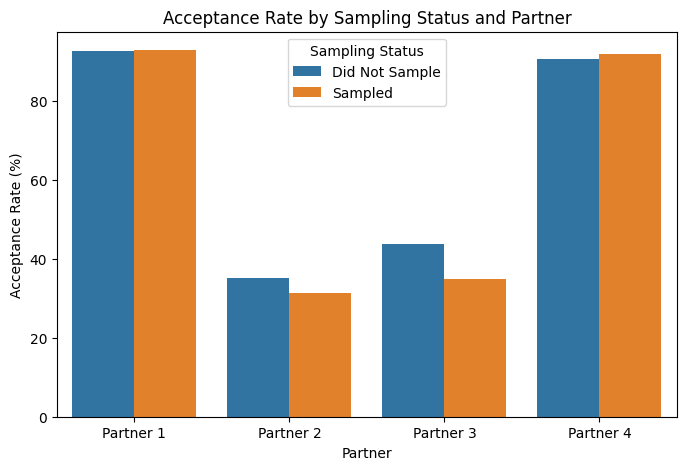

     Partner    Chi2         p    Phi
0  Partner 1   0.023  0.878434  0.002
1  Partner 2   3.501  0.061348  0.027
2  Partner 3  23.871  0.000001  0.072
3  Partner 4   2.163  0.141326  0.022


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv(r"https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/Projects/Ahmad/CityLab_raw.csv")

rows=[]
for partner in range(1,5):
    idx=list(range((partner-1)*5+1,partner*5+1))+list(range(20+(partner-1)*5+1,20+partner*5+1))
    button_cols=[f'button{i}_clicks' for i in idx]
    sampled=df[button_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).gt(0)
    decision=df[f'Offer{partner}']
    for sampling_label, mask in [('Did Not Sample', ~sampled), ('Sampled', sampled)]:
        valid=mask & decision.notna()
        n=int(valid.sum())
        accepted=int((decision[valid]=='Accept').sum())
        rejected=int((decision[valid]=='Reject').sum())
        rows.append({'partner':f'Partner {partner}','sampling_status':sampling_label,'n_decisions':n,'accepted':accepted,'rejected':rejected,'acceptance_rate_pct':100*accepted/n})
chart_data=pd.DataFrame(rows)
chart_data['sampling_status']=pd.Categorical(chart_data['sampling_status'], ['Did Not Sample','Sampled'], ordered=True)
plt.figure(figsize=(8, 5))
sns.barplot(data=chart_data, x='partner', y='acceptance_rate_pct',
            hue='sampling_status', palette=['#1f77b4', '#ff7f0e'])
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Partner')
plt.title('Acceptance Rate by Sampling Status and Partner')
plt.legend(title='Sampling Status')
plt.show()

results = []

for partner in chart_data['partner'].unique():

    tmp = chart_data[chart_data['partner'] == partner]

    table = pd.DataFrame({
        'Accept': [
            tmp.loc[tmp['sampling_status'] == 'Did Not Sample', 'accepted'].iloc[0],
            tmp.loc[tmp['sampling_status'] == 'Sampled', 'accepted'].iloc[0]
        ],
        'Reject': [
            tmp.loc[tmp['sampling_status'] == 'Did Not Sample', 'rejected'].iloc[0],
            tmp.loc[tmp['sampling_status'] == 'Sampled', 'rejected'].iloc[0]
        ]
    }, index=['Did Not Sample', 'Sampled'])

    chi2, p, dof, expected = chi2_contingency(table, correction=False)

    n = table.to_numpy().sum()
    phi = np.sqrt(chi2 / n)


    results.append({
        'Partner': partner,
        'N': n,
        'Accept_DNS_%': 100 * table.loc['Did Not Sample', 'Accept'] / table.loc['Did Not Sample'].sum(),
        'Accept_Sampled_%': 100 * table.loc['Sampled', 'Accept'] / table.loc['Sampled'].sum(),
        'Chi2': chi2,
        'df': dof,
        'p': p,
        'Phi': phi
    })

results_df = pd.DataFrame(results)

print(
    results_df[['Partner','Chi2','p','Phi']].round({
        'Chi2': 3,
        'p': 6,
        'Phi': 3
    })
)

